# **Hotzel Steam: Comparative Regression Analysis - Seana Maennling**

To begin my analysis, I will start by uploading libraries, assigning the dataset a name, and removing scientific notation in Python. Please see the following preparations below:

In [ ]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assigning a name to dataset

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

# To remove scientific notation, including this line at the top of my Colab file

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# Taking a look at the dataset

HS_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   type        48 non-null     object
 1   date        48 non-null     object
 2   revenue     48 non-null     int64 
 3   production  48 non-null     int64 
 4   coolDD      48 non-null     int64 
 5   heatDD      48 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.4+ KB


In [ ]:
# Now I will ensure that the 'date' variable actually shows as a date

HS_data['date'] = pd.to_datetime(HS_data['date'])

The next preparations I must make for the analysis is using the correlation function, and separating my data into training and testing.

In [ ]:
# .corr() -> correlation function
# Using this to find quantitative relationships between variables

HS_data.loc[:,['revenue','production','coolDD','heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


In [ ]:
#  Separating data into training and testing sets using the .loc function

dt4training = HS_data.loc[HS_data['type'] == 'dt4training']
dt4testing = HS_data.loc[HS_data['type'] == 'dt4testing']

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166


Now that the data prep is complete, I need to begin creating **Model 1**: (revenue and production)

In [ ]:
# MODEL 1 -> revenue and production

# Preparing the dependent variable by using .loc on the column I want to predict (y = revenue)
y = dt4training.loc[:,'revenue']

# Preparing the independent variable by using .loc on the column I want (x = production)
x = dt4training.loc[:,'production']

# Preparing the constant by taking independent (x) value and adding a constant
x = sm.add_constant(x)

# Now I can train the model using the OLS function
# Using OLS(y,x).fit()
# Naming the model as model1
model1 = sm.OLS(y,x).fit()

# Using .summary() to see model1 results
model1.summary()

# Looking at parameters
model1.params

,0
const,4897663.26
production,18.99


In [ ]:
# To test the model, I am removing anything related to the dependent variable
# Here I am preparing the testing side of the regression model

x_test = dt4testing.loc[:,'production']
x_test = sm.add_constant(x_test)

In [ ]:
# To actually test the model, I am using modelName.predict(testing preparation)

model1.predict(x_test)

,0
36,16414428.69
37,18460401.82
38,20197640.55
39,12035930.72
40,10202060.55
41,14727936.65
42,19131656.04
43,17497582.00
44,18223533.25
45,12717212.73


**Model 1** MAPE score: see process below

In [ ]:
# Step 1: Copying over testing data to an assessment dataframe so I don't mess up the testing data
model1_assessment = dt4testing.copy()

# Step 2: Adding predicted values (in this case predicted revenues) to the assessment dataframe
model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

# Step 3: Creating a column for absolute percentage error for every row
model1_assessment['model1_pctError'] = abs(
    (model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']) / model1_assessment['revenue']
    )

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


In [ ]:
# Step 4: Finding the mean of that percentage error column
model1_assessment['model1_pctError'].mean()

# Model 1 MAPE score is about 25%

np.float64(0.2542315606071484)

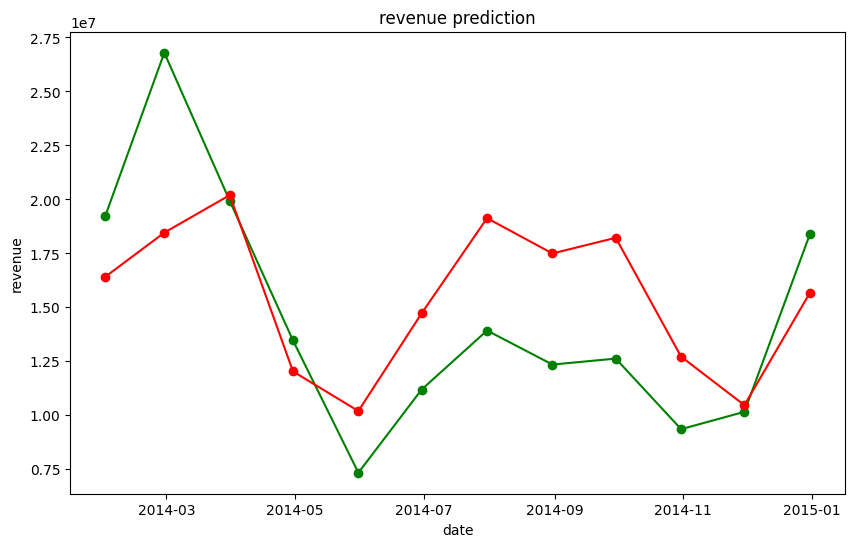

In [ ]:
# Step 5: Visualization

plt.figure(figsize=(10,6))
plt.title('revenue prediction')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'],model1_assessment['revenue'],marker='o', color='green')
plt.plot(model1_assessment['date'],model1_assessment['model1_predicted_revenue'],marker='o', color='red')

Now, I need to replicate the same process for **Model 2** (revenue and heatDD)

In [ ]:
# MODEL 2 -> revenue and heatDD

# Preparing the dependent variable by using .loc on the column I want to predict (y2 = revenue)
y2 = dt4training.loc[:,'revenue']

# Preparing the independent variable by using .loc on the column I want (x2 = heatDD)
x2 = dt4training.loc[:,'heatDD']

# Preparing the constant by taking independent (x2) value and adding a constant
x2 = sm.add_constant(x2)

# Now I can train the model using the OLS function
# Using OLS(y,x2).fit()
# Naming the model as model1
model2 = sm.OLS(y,x2).fit()

# Using .summary() to see model2 results
model2.summary()

# Looking at parameters
model2.params

,0
const,10333861.28
heatDD,9991.26


In [ ]:
# To test the model, I am removing anything related to the dependent variable
# Here I am preparing the testing side of the regression model

x2_test = dt4testing.loc[:,'heatDD']
x2_test = sm.add_constant(x2_test)

In [ ]:
# To actually test the model, I am using modelName.predict(testing preparation)

model2.predict(x2_test)

,0
36,21554043.42
37,19705660.79
38,18986290.25
39,14450259.35
40,11213091.93
41,10333861.28
42,10333861.28
43,10333861.28
44,10473738.88
45,11992410.02


**Model 2** MAPE score: see process below

In [ ]:
# Step 1: Copying over testing data to an assessment dataframe so I don't mess up the testing data
model2_assessment = dt4testing.copy()

# Step 2: Adding predicted values (in this case predicted revenues) to the assessment dataframe
model2_assessment['model2_predicted_revenue'] = model2.predict(x2_test)

# Step 3: Creating a column for absolute percentage error for every row
model2_assessment['model2_pctError'] = abs(
    (model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue']) / model2_assessment['revenue']
    )

display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,model2_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,21554043.42,0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,19705660.79,0.26
38,dt4testing,2014-03-31,19935840,805600,0,866,18986290.25,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,14450259.35,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,11213091.93,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,10333861.28,0.08
42,dt4testing,2014-07-31,13929472,749472,380,0,10333861.28,0.26
43,dt4testing,2014-08-31,12352176,663432,322,0,10333861.28,0.16
44,dt4testing,2014-09-30,12628944,701656,178,14,10473738.88,0.17
45,dt4testing,2014-10-31,9361000,411728,24,166,11992410.02,0.28


In [ ]:
# Step 4: Finding the mean of that percentage error column
model2_assessment['model2_pctError'].mean()

# Model 2 MAPE score is about 22%

np.float64(0.21648503280089135)

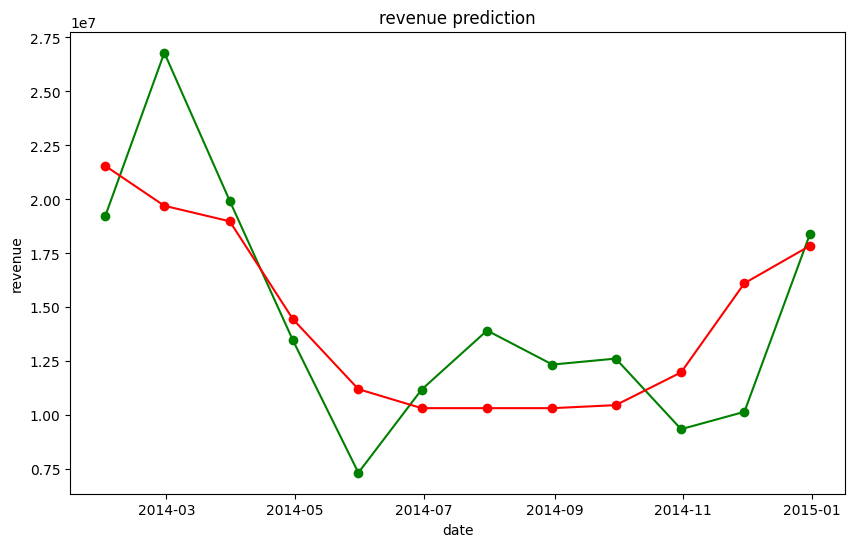

In [ ]:
import matplotlib.pyplot as plt

# Step 5: Visualization

plt.figure(figsize=(10,6))
plt.title('revenue prediction')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model2_assessment['date'],model2_assessment['revenue'],marker='o', color='green')
plt.plot(model2_assessment['date'],model2_assessment['model2_predicted_revenue'],marker='o', color='red')